In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression 

**EDA**

In [2]:
df = pd.read_csv(r"Life Expectancy Data.csv")
df.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [3]:
print(df.shape)
print(df.dtypes)

(2938, 22)
Country                             object
Year                                 int64
Status                              object
Life expectancy                    float64
Adult Mortality                    float64
infant deaths                        int64
Alcohol                            float64
percentage expenditure             float64
Hepatitis B                        float64
Measles                              int64
 BMI                               float64
under-five deaths                    int64
Polio                              float64
Total expenditure                  float64
Diphtheria                         float64
 HIV/AIDS                          float64
GDP                                float64
Population                         float64
 thinness  1-19 years              float64
 thinness 5-9 years                float64
Income composition of resources    float64
Schooling                          float64
dtype: object


In [4]:
nullValues = df.isnull().sum()
print(nullValues / len(df))

Country                            0.000000
Year                               0.000000
Status                             0.000000
Life expectancy                    0.003404
Adult Mortality                    0.003404
infant deaths                      0.000000
Alcohol                            0.066031
percentage expenditure             0.000000
Hepatitis B                        0.188223
Measles                            0.000000
 BMI                               0.011572
under-five deaths                  0.000000
Polio                              0.006467
Total expenditure                  0.076923
Diphtheria                         0.006467
 HIV/AIDS                          0.000000
GDP                                0.152485
Population                         0.221920
 thinness  1-19 years              0.011572
 thinness 5-9 years                0.011572
Income composition of resources    0.056841
Schooling                          0.055480
dtype: float64


From the observations, I can tell GDP (15%), Population (22%) and Hepatitis B (18.8%) are the columns with most missing values. Other notable ones include Total Expenditure (7.7%), Alcohol (6.6%), Income (5.7%) and Schooling (5.5%).

In [5]:
print(df.describe())

              Year  Life expectancy   Adult Mortality  infant deaths  \
count  2938.000000       2928.000000      2928.000000    2938.000000   
mean   2007.518720         69.224932       164.796448      30.303948   
std       4.613841          9.523867       124.292079     117.926501   
min    2000.000000         36.300000         1.000000       0.000000   
25%    2004.000000         63.100000        74.000000       0.000000   
50%    2008.000000         72.100000       144.000000       3.000000   
75%    2012.000000         75.700000       228.000000      22.000000   
max    2015.000000         89.000000       723.000000    1800.000000   

           Alcohol  percentage expenditure  Hepatitis B       Measles   \
count  2744.000000             2938.000000  2385.000000    2938.000000   
mean      4.602861              738.251295    80.940461    2419.592240   
std       4.052413             1987.914858    25.070016   11467.272489   
min       0.010000                0.000000     1.000000

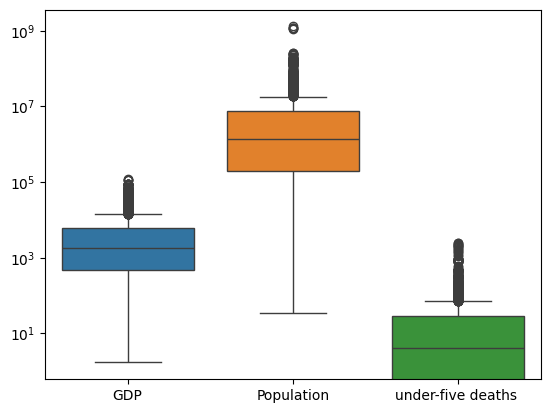

In [6]:
colsToCheck = ['GDP', 'Population', 'under-five deaths ']
sns.boxplot(data=df[colsToCheck])
plt.yscale('log')
plt.show()

Filling in the missing values

In [7]:
df['GDP'] = df['GDP'].fillna(df['GDP'].median())
df['Hepatitis B'] = df['Hepatitis B'].fillna(df['Hepatitis B'].median())

df['Population'] = df['Population'].fillna(df['Population'].mean())
df['Total expenditure'] = df['Total expenditure'].fillna(df['Total expenditure'].mean())
df['Income composition of resources'] = df['Income composition of resources'].fillna(df['Income composition of resources'].mean())
df['Schooling'] = df['Schooling'].fillna(df['Schooling'].mean())
df['Alcohol'] = df['Alcohol'].fillna(df['Alcohol'].mean())

In [8]:
#The other remaining columns
df['Life expectancy '] = df['Life expectancy '].fillna(df['Life expectancy '].median())
df['Adult Mortality'] = df['Adult Mortality'].fillna(df['Adult Mortality'].median())
df[' BMI '] = df[' BMI '].fillna(df[' BMI '].median())
df['Polio'] = df['Polio'].fillna(df['Polio'].median())
df['Diphtheria '] = df['Diphtheria '].fillna(df['Diphtheria '].median())
df[' thinness  1-19 years'] = df[' thinness  1-19 years'].fillna(df[' thinness  1-19 years'].median())
df[' thinness 5-9 years'] = df[' thinness 5-9 years'].fillna(df[' thinness 5-9 years'].median())

In [9]:
df['Population'] = np.log1p(df['Population'])
df['GDP'] = np.log1p(df['GDP'])

In [10]:
df['Status'] = df['Status'].map({'Developed': 1, 'Developing': 0})

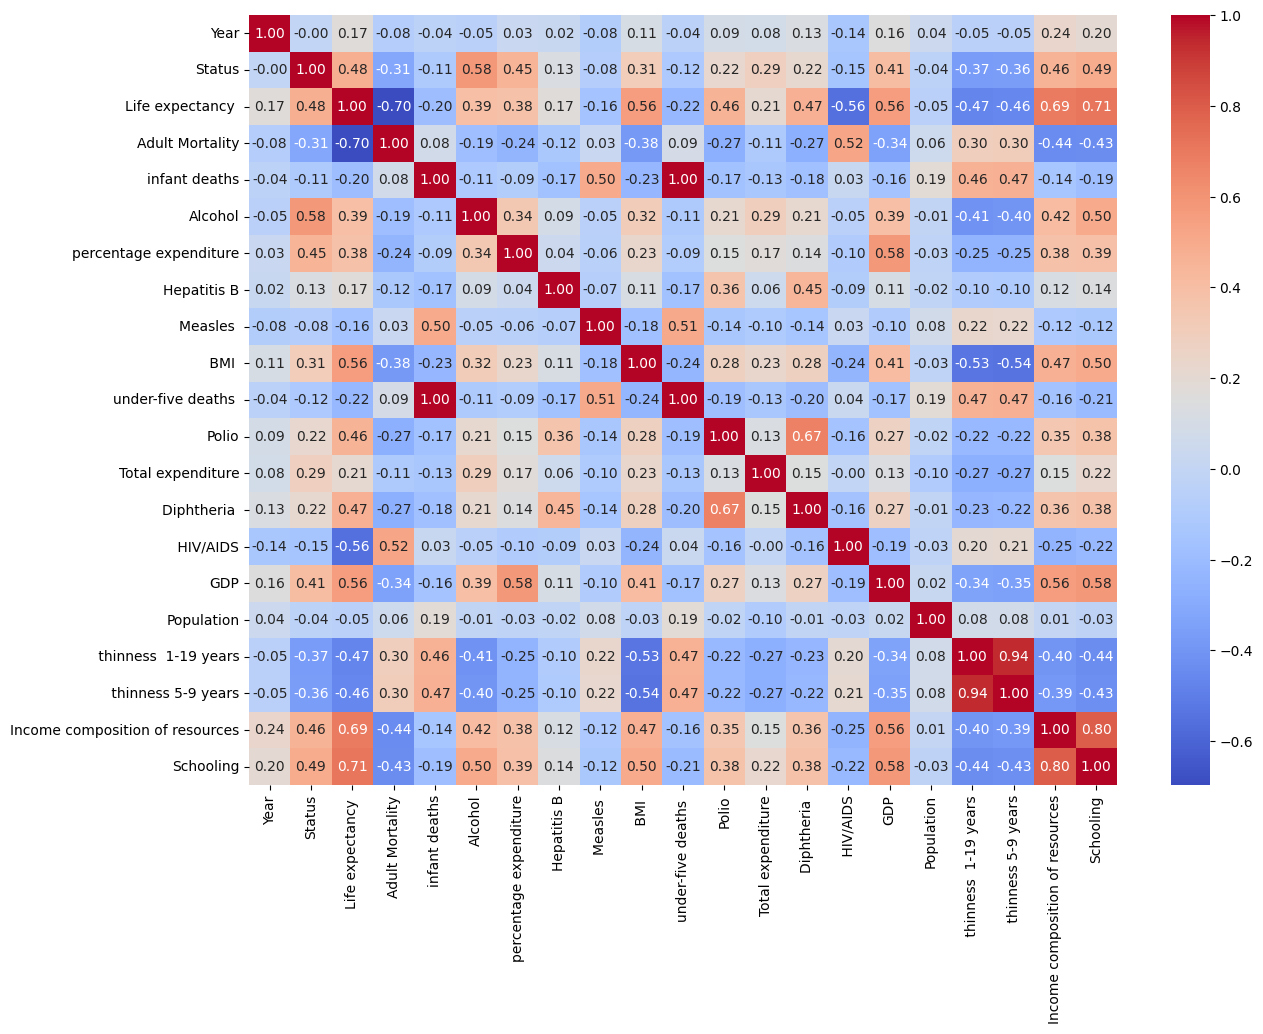

In [11]:
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

<Axes: >

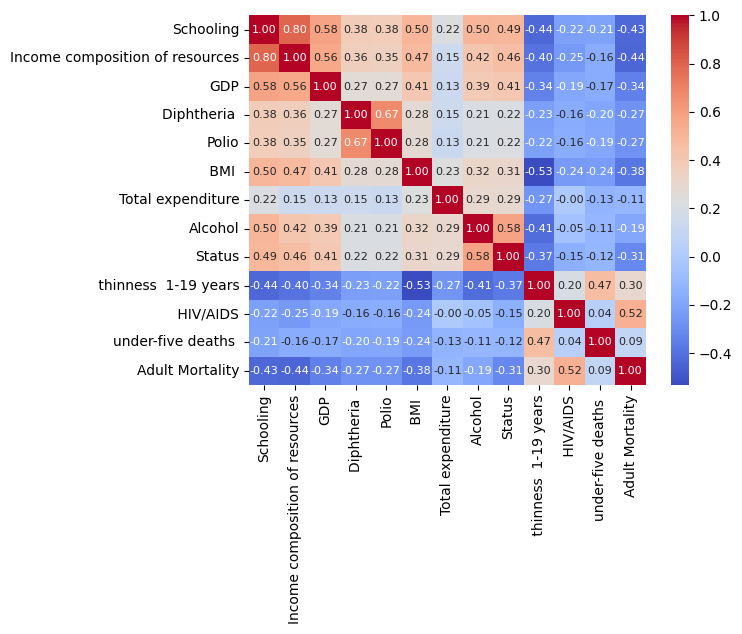

In [12]:
strong_features = ["Schooling", "Income composition of resources", "GDP",
                   "Diphtheria ", "Polio", " BMI ", "Total expenditure",
                    "Alcohol", "Status", " thinness  1-19 years", " HIV/AIDS",
                    "under-five deaths ", "Adult Mortality"]
sns.heatmap(df[strong_features].corr(), annot=True, cmap='coolwarm', fmt='.2f', annot_kws={"size": 8})

In [13]:
from sklearn.model_selection import train_test_split

X = df[strong_features]
y = df["Life expectancy "]
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y,
    test_size=0.2,
    random_state=30,
    shuffle=True
)

In [14]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [15]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](13,)","[ 1.97, 1.2 , 0.83,...,-2.41,-0.22,-2.57]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,69.44
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,13
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,13
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](13,)","[106.26, 56.84, 53.94,..., 28.64, 28.18, 21.6 ]"


In [16]:
y_pred = model.predict(X_test_scaled)

In [20]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

#R2 essentially shows how much of the variance in target variable is explained 
#by the predictors
r2 = r2_score(y_test, y_pred)
print(f"R-Squared: {r2:.4f}")

mse = mean_squared_error(y_test, y_pred)
print(f"MSE: {mse:.4f}")

rmse = mse ** 0.5
print(f"RMSE: {rmse:.4f}")

mae = mean_absolute_error(y_test, y_pred)
print(f"MAE: {mae:.4f}")

R-Squared: 0.8011
MSE: 19.1811
RMSE: 4.3796
MAE: 3.3203


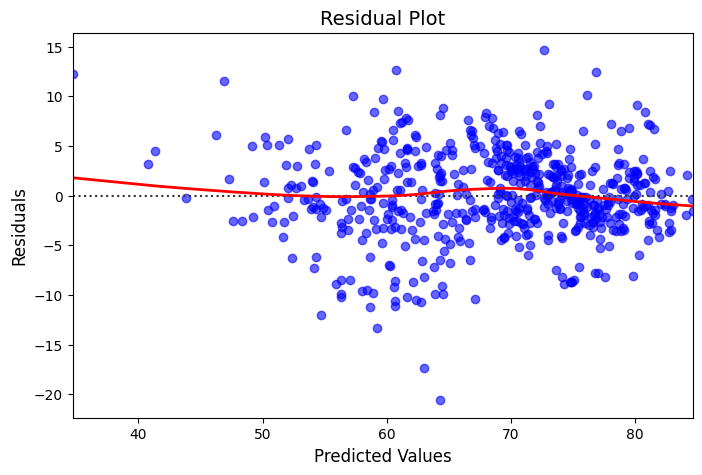

In [18]:
plt.figure(figsize=(8, 5))

sns.residplot(x=y_pred, y=y_test, lowess=True, color="blue", scatter_kws={'alpha': 0.6}, line_kws={'color': 'red', 'lw': 2})


plt.xlabel('Predicted Values', fontsize=12)
plt.ylabel('Residuals', fontsize=12)
plt.title('Residual Plot', fontsize=14)

plt.show()

In [19]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

print(f"Intercept: {model.intercept_}")
print(coefficients)

Intercept: 69.44306382978723
                            Feature  Coefficient
0                         Schooling     1.968790
1   Income composition of resources     1.203731
2                               GDP     0.826832
3                       Diphtheria      1.028157
4                             Polio     0.650032
5                              BMI      0.848909
6                 Total expenditure     0.204852
7                           Alcohol     0.093326
8                            Status     0.618904
9              thinness  1-19 years    -0.365915
10                         HIV/AIDS    -2.406701
11               under-five deaths     -0.215675
12                  Adult Mortality    -2.570694
